In [2]:
import numpy as np
import pandas as pd

In [3]:
df = pd.read_csv('dataset.csv')

In [4]:
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  str    
 1   availability  13320 non-null  str    
 2   location      13319 non-null  str    
 3   size          13304 non-null  str    
 4   society       7818 non-null   str    
 5   total_sqft    13320 non-null  str    
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), str(6)
memory usage: 936.7 KB


In [6]:
df['area_type'].value_counts()

area_type
Super built-up  Area    8790
Built-up  Area          2418
Plot  Area              2025
Carpet  Area              87
Name: count, dtype: int64

In [7]:
df['size'].value_counts()

size
2 BHK         5199
3 BHK         4310
4 Bedroom      826
4 BHK          591
3 Bedroom      547
1 BHK          538
2 Bedroom      329
5 Bedroom      297
6 Bedroom      191
1 Bedroom      105
8 Bedroom       84
7 Bedroom       83
5 BHK           59
9 Bedroom       46
6 BHK           30
7 BHK           17
1 RK            13
10 Bedroom      12
9 BHK            8
8 BHK            5
11 BHK           2
11 Bedroom       2
10 BHK           2
27 BHK           1
19 BHK           1
16 BHK           1
43 Bedroom       1
14 BHK           1
12 Bedroom       1
13 BHK           1
18 Bedroom       1
Name: count, dtype: int64

In [8]:
df['availability'].value_counts()

availability
Ready To Move    10581
18-Dec             307
18-May             295
18-Apr             271
18-Aug             200
                 ...  
15-Aug               1
17-Jan               1
16-Nov               1
16-Jan               1
14-Jul               1
Name: count, Length: 81, dtype: int64

In [9]:
df['bath'].value_counts()

bath
2.0     6908
3.0     3286
4.0     1226
1.0      788
5.0      524
6.0      273
7.0      102
8.0       64
9.0       43
10.0      13
12.0       7
11.0       3
13.0       3
16.0       2
14.0       1
27.0       1
40.0       1
15.0       1
18.0       1
Name: count, dtype: int64

In [10]:
# EDA finindings:
#0. Area_type is having just 4 categories and that would affect a lot along with the total_sqft as plot_area category with total_sqft would have higher space and super builtup area with sq_feet
#1. availabilty has ready to move and specific dates. The specific dates can be simply converted to not ready to move. So we will have just 2 categories in it
#2. location has lots of categories... how to handle those many categories => 
#3. size also has bhk as well as bedroom setup like 2bhk, 2 bedrooms both are same thing and there are multiple such instances for 3bhk, 4, 5 and so on => maybe let's convert first all the 'bedroom' columns to bhk. Then there would still be some duplicate columns so those duplicate columns can be merged.
#4. society column has 5502 empty rows, how to fix that? => I think it won't be having a major correlation with the price. though it maybe possible that if a society belongs to a locality in that city and that locality may demand a premium, so there is still a chance but having so many null values meaning the feature maynot be explored by model?
#5. Total_sqft, I feel this will be the highly correlative feature to the target column which is price
#6. bath should be the number of bathroom the house has and 73 rows have null values => more number of bathrooms could mean more the price, so better to keep the null values as is
#7. balcony has 609 rows empty => balcony may have good correlation with price column so it's better to keep emtpy in the data since imputing any value can introduce bias?

In [11]:
df['location'].value_counts()

location
Whitefield                                         540
Sarjapur  Road                                     399
Electronic City                                    302
Kanakpura Road                                     273
Thanisandra                                        234
                                                  ... 
Pattegarhpalya                                       1
Tilak Nagar                                          1
12th cross srinivas nagar banshankari 3rd stage      1
Havanur extension                                    1
Abshot Layout                                        1
Name: count, Length: 1305, dtype: int64

In [12]:
df['location'].isnull().sum()

np.int64(1)

In [13]:
counts = df['location'].value_counts()

total_single = (counts == 1).sum()
print("how many are appeared just once", total_single)

above_ten = (counts > 10).sum()
print("how many are above 10 have appeared", above_ten)

how many are appeared just once 480
how many are above 10 have appeared 241


# 3 ways to handle the location issue ->
#since location has 1308 values we cannot use normal one-hot encoding since it would increase the columns to huge numbers
#1. frequency encoding replaces the frequency of that category with that actual categorical value. 
#2. in case there are so many categories but appearing just once then those can be categorised in others.
#3. Target encoding => This replaces each category with the average value for that specific category. And this actually makes sense since the houses specific to that location can be seen as an average of the target price.

#analysis :
#out of 1308 locations there are 480 locations which appears just once
#but there are still 241 categories which appeared more than 10 times. And that too is a huge number to handle with OHE, so can't use the 2nd way.


So, I have **1,308 localities**, where the most common locality appears **540 times**, the second most common appears **399 times**, and so on. Also, around **480 localities appear only once**.

with K-Fold Target Encoding, am I going to ignore those 540 rows of the most common locality when calculating its encoding?

Or, that I have to divide the entire dataset into **5 folds**? For example, if I have around **13,000 rows**, each fold will have around **2,600–2,700 rows**.

Then:

* **Fold 1** is encoded using the target values from Folds 2, 3, 4, and 5.
* **Fold 2** is encoded using Folds 1, 3, 4, and 5.
* **Fold 3** is encoded using Folds 1, 2, 4, and 5.
* And so on.

This way, **every row gets its target encoding calculated using other rows, not using its own fold**.

So, even for the locality that appears 540 times, I don't simply ignore those rows. I use the other folds to calculate its target encoding.

The main benefit is that the target value from a particular fold is **not used to encode that same fold**, which helps prevent **target leakage**.

Even the localities that appear only once are handled. If a locality appears only once in Fold 1, its encoding can be calculated from the other four folds. However, because it has very little data, its encoding may be less reliable.

The rare 480 single-occurrence locations are the interesting edge case — with only 1 row, 4 of the 5 folds will have zero rows for that location to calculate a mean from. The standard solution is a smoothing parameter:
Encoded value = (count × location_mean + global_mean × smoothing) / (count + smoothing)

In [14]:
df['bath'].isnull().sum()

np.int64(73)

In [15]:
df.loc[df['bath'].isna(), 'size']

56       4 Bedroom
81       4 Bedroom
224          3 BHK
344          1 BHK
579            NaN
           ...    
11496        1 BHK
11569          NaN
12768    5 Bedroom
12861        4 BHK
13240        1 BHK
Name: size, Length: 73, dtype: str

For handling the bathroom and balcony column I can take median of those associated sizes. for e.g the 2bhk median for bath across data
maybe 2 and so that would be applied to the null values. And this technique will be applied to both bath and balcony

In [16]:
#fixing the size column..
df['size_filled'] = df['size'].str.replace(r'(\d+)\s*bedroom', r'\1 BHK', case=False, regex=True)

In [17]:
df['size_filled'].isnull().sum()

np.int64(16)

In [18]:
df['size'].isnull().sum()

np.int64(16)

In [19]:
df[df['size'].isna()]

,area_type,availability,location,size,society,total_sqft,bath,balcony,price,size_filled
579,Plot Area,Immediate Possession,Sarjapur Road,NaN,Asiss B,1200 - 2400,NaN,NaN,34.185,NaN
1775,Plot Area,Immediate Possession,IVC Road,NaN,Orana N,2000 - 5634,NaN,NaN,124.000,NaN
2264,Plot Area,Immediate Possession,Banashankari,NaN,NaN,2400,NaN,NaN,460.000,NaN
2809,Plot Area,Immediate Possession,Sarjapur Road,NaN,AsdiaAr,1200 - 2400,NaN,NaN,28.785,NaN
2862,Plot Area,Immediate Possession,Devanahalli,NaN,Ajleyor,1500 - 2400,NaN,NaN,46.800,NaN
5333,Plot Area,Immediate Possession,Devanahalli,NaN,Emngs S,2100 - 5405,NaN,NaN,177.115,NaN
6423,Plot Area,Immediate Possession,Whitefield,NaN,SRniaGa,2324,NaN,NaN,26.730,NaN
6636,Plot Area,Immediate Possession,Jigani,NaN,S2enste,1500,NaN,NaN,25.490,NaN
6719,Plot Area,Immediate Possession,Hoskote,NaN,SJowsn,800 - 2660,NaN,NaN,28.545,NaN
7680,Plot Area,Immediate Possession,Kasavanhalli,NaN,NaN,5000,NaN,NaN,400.000,NaN


In [20]:
df = df.dropna(subset=['size', 'size_filled'])

In [21]:
df

,area_type,availability,location,size,society,total_sqft,bath,balcony,price,size_filled
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07,2 BHK
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00,4 BHK
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00,3 BHK
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00,3 BHK
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00,2 BHK
...,...,...,...,...,...,...,...,...,...,...
13315,Built-up Area,Ready To Move,Whitefield,5 Bedroom,ArsiaEx,3453,4.0,0.0,231.00,5 BHK
13316,Super built-up Area,Ready To Move,Richards Town,4 BHK,NaN,3600,5.0,NaN,400.00,4 BHK
13317,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,2 BHK,Mahla T,1141,2.0,1.0,60.00,2 BHK
13318,Super built-up Area,18-Jun,Padmanabhanagar,4 BHK,SollyCl,4689,4.0,1.0,488.00,4 BHK


In [22]:
#important observations..
#1. size is null for 16 rows.
#2. the sqfeet is also is in the range

#issues to solve
#1. take decision about null size values
#2. sort out the range issue with the sqfeet column
#3. impute the values for bath and balcony
#4. Do the location encoding.

In [23]:
df['size_filled'].isna().sum()

np.int64(0)

In [24]:
df.shape

(13304, 10)

In [25]:
df

,area_type,availability,location,size,society,total_sqft,bath,balcony,price,size_filled
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07,2 BHK
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00,4 BHK
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00,3 BHK
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00,3 BHK
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00,2 BHK
...,...,...,...,...,...,...,...,...,...,...
13315,Built-up Area,Ready To Move,Whitefield,5 Bedroom,ArsiaEx,3453,4.0,0.0,231.00,5 BHK
13316,Super built-up Area,Ready To Move,Richards Town,4 BHK,NaN,3600,5.0,NaN,400.00,4 BHK
13317,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,2 BHK,Mahla T,1141,2.0,1.0,60.00,2 BHK
13318,Super built-up Area,18-Jun,Padmanabhanagar,4 BHK,SollyCl,4689,4.0,1.0,488.00,4 BHK


In [26]:
df.info()

<class 'pandas.DataFrame'>
Index: 13304 entries, 0 to 13319
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13304 non-null  str    
 1   availability  13304 non-null  str    
 2   location      13303 non-null  str    
 3   size          13304 non-null  str    
 4   society       7805 non-null   str    
 5   total_sqft    13304 non-null  str    
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13304 non-null  float64
 9   size_filled   13304 non-null  str    
dtypes: float64(3), str(7)
memory usage: 1.1 MB


In [27]:
#removing society since it has around 5k null values.. and since location is the column which is already present that makes the society column redundant
df = df.drop(columns=['society'])

In [28]:
df

,area_type,availability,location,size,total_sqft,bath,balcony,price,size_filled
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,1056,2.0,1.0,39.07,2 BHK
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,2600,5.0,3.0,120.00,4 BHK
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,1440,2.0,3.0,62.00,3 BHK
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,1521,3.0,1.0,95.00,3 BHK
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,1200,2.0,1.0,51.00,2 BHK
...,...,...,...,...,...,...,...,...,...
13315,Built-up Area,Ready To Move,Whitefield,5 Bedroom,3453,4.0,0.0,231.00,5 BHK
13316,Super built-up Area,Ready To Move,Richards Town,4 BHK,3600,5.0,NaN,400.00,4 BHK
13317,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,2 BHK,1141,2.0,1.0,60.00,2 BHK
13318,Super built-up Area,18-Jun,Padmanabhanagar,4 BHK,4689,4.0,1.0,488.00,4 BHK


In [29]:
df.info()

<class 'pandas.DataFrame'>
Index: 13304 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13304 non-null  str    
 1   availability  13304 non-null  str    
 2   location      13303 non-null  str    
 3   size          13304 non-null  str    
 4   total_sqft    13304 non-null  str    
 5   bath          13247 non-null  float64
 6   balcony       12711 non-null  float64
 7   price         13304 non-null  float64
 8   size_filled   13304 non-null  str    
dtypes: float64(3), str(6)
memory usage: 1.0 MB


In [30]:
#important observations..
#1. size is null for 16 rows.
#2. the sqfeet is also is in the range

#issues to solve
#1. take decision about null size values
#2. sort out the range issue with the sqfeet column
#3. impute the values for bath and balcony => this will be imputed from the average
#4. Do the location encoding. 

In [31]:
df.loc[df['bath'].isna(), 'size_filled']

56       4 BHK
81       4 BHK
224      3 BHK
344      1 BHK
669      5 BHK
702      5 BHK
801      4 BHK
941      4 BHK
1264     3 BHK
1267     3 BHK
1686     1 BHK
1724     1 BHK
1765     4 BHK
1852     4 BHK
2500     4 BHK
2563     4 BHK
2944     3 BHK
2998     3 BHK
3370     3 BHK
3544     3 BHK
3598     4 BHK
3862     4 BHK
4210     3 BHK
4346     3 BHK
4843     4 BHK
4894     3 BHK
4995     3 BHK
5464     3 BHK
5498     4 BHK
5747     1 BHK
5918     4 BHK
6256     4 BHK
6343     3 BHK
6481     3 BHK
6778     4 BHK
6873     3 BHK
6971     3 BHK
7398     3 BHK
7623     3 BHK
7921     3 BHK
8020     4 BHK
8056     3 BHK
8275     1 BHK
8289     2 BHK
8472     4 BHK
8783     3 BHK
9129     3 BHK
9437     4 BHK
9699     4 BHK
10330    3 BHK
10553    4 BHK
10726    3 BHK
11297    4 BHK
11496    1 BHK
12768    5 BHK
12861    4 BHK
13240    1 BHK
Name: size_filled, dtype: str

In [32]:
#to impute bath => how to get the empty bath row and check its filled_size if filled_size is 2bhk then impute that empty value with median value for that size filled value

#1. calculate the median value for bath per bhk
df.groupby('size_filled')['bath'].median()

#2. fillna for bath
df[df['bath'].isnull()==True]

,area_type,availability,location,size,total_sqft,bath,balcony,price,size_filled
56,Built-up Area,20-Feb,Devanahalli,4 Bedroom,3010 - 3410,NaN,NaN,192.000,4 BHK
81,Built-up Area,18-Oct,Hennur Road,4 Bedroom,2957 - 3450,NaN,NaN,224.500,4 BHK
224,Super built-up Area,19-Dec,Devanahalli,3 BHK,1520 - 1740,NaN,NaN,74.820,3 BHK
344,Super built-up Area,21-Dec,Kanakpura Road,1 BHK,525,NaN,NaN,21.530,1 BHK
669,Super built-up Area,18-Dec,JP Nagar,5 BHK,4400 - 6640,NaN,NaN,375.000,5 BHK
702,Super built-up Area,18-Dec,JP Nagar,5 BHK,4400 - 6800,NaN,NaN,548.500,5 BHK
801,Super built-up Area,18-Dec,JP Nagar,4 BHK,4000 - 5249,NaN,NaN,453.000,4 BHK
941,Super built-up Area,Ready To Move,Whitefield,4 Bedroom,3606 - 5091,NaN,NaN,304.000,4 BHK
1264,Built-up Area,18-May,Hennur,3 Bedroom,2264,NaN,NaN,155.000,3 BHK
1267,Super built-up Area,18-Jun,Yelahanka,3 BHK,1440 - 1884,NaN,NaN,67.980,3 BHK


In [33]:
grouped_bath_medians = df.groupby('size_filled')['bath'].transform('median')
df['bath'] = df['bath'].fillna(grouped_bath_medians)

In [34]:
df[df['bath'].isnull()==True]

,area_type,availability,location,size,total_sqft,bath,balcony,price,size_filled


In [35]:
df.info()

<class 'pandas.DataFrame'>
Index: 13304 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13304 non-null  str    
 1   availability  13304 non-null  str    
 2   location      13303 non-null  str    
 3   size          13304 non-null  str    
 4   total_sqft    13304 non-null  str    
 5   bath          13304 non-null  float64
 6   balcony       12711 non-null  float64
 7   price         13304 non-null  float64
 8   size_filled   13304 non-null  str    
dtypes: float64(3), str(6)
memory usage: 1.0 MB


In [36]:
#same way imputing the balcony

In [37]:
df[df['balcony'].isnull() == True]

,area_type,availability,location,size,total_sqft,bath,balcony,price,size_filled
6,Super built-up Area,18-May,Old Airport Road,4 BHK,2732,4.0,NaN,204.00,4 BHK
7,Super built-up Area,Ready To Move,Rajaji Nagar,4 BHK,3300,4.0,NaN,600.00,4 BHK
9,Plot Area,Ready To Move,Gandhi Bazar,6 Bedroom,1020,6.0,NaN,370.00,6 BHK
34,Built-up Area,Ready To Move,Kasturi Nagar,3 BHK,1925,3.0,NaN,125.00,3 BHK
40,Built-up Area,Ready To Move,Murugeshpalya,2 BHK,1296,2.0,NaN,81.00,2 BHK
...,...,...,...,...,...,...,...,...,...
13277,Plot Area,Ready To Move,Kundalahalli Colony,7 Bedroom,1400,7.0,NaN,218.00,7 BHK
13279,Plot Area,Ready To Move,Vishwanatha Nagenahalli,6 Bedroom,1200,5.0,NaN,130.00,6 BHK
13306,Plot Area,Ready To Move,Rajarajeshwari Nagara,4 Bedroom,1200,5.0,NaN,325.00,4 BHK
13309,Super built-up Area,Ready To Move,Yeshwanthpur,3 BHK,1675,3.0,NaN,92.13,3 BHK


In [38]:
grouped_balcony_median = df.groupby('size_filled')['balcony'].transform('median')
df['balcony'] = df['balcony'].fillna(grouped_balcony_median)

In [39]:
df[df['balcony'].isnull() == True]

,area_type,availability,location,size,total_sqft,bath,balcony,price,size_filled
3379,Super built-up Area,Ready To Move,1Hanuman Nagar,19 BHK,2000,16.0,NaN,490.0,19 BHK
3609,Super built-up Area,Ready To Move,Koramangala Industrial Layout,16 BHK,10000,16.0,NaN,550.0,16 BHK
11559,Plot Area,18-Apr,1Kasavanhalli,18 Bedroom,1200,18.0,NaN,200.0,18 BHK


In [40]:
df[df['size_filled'] == '18 BHK']

,area_type,availability,location,size,total_sqft,bath,balcony,price,size_filled
11559,Plot Area,18-Apr,1Kasavanhalli,18 Bedroom,1200,18.0,NaN,200.0,18 BHK


In [41]:
#Size_filled column has to be checked if it's normally distributed
import seaborn as sns
import matplotlib.pyplot as plt

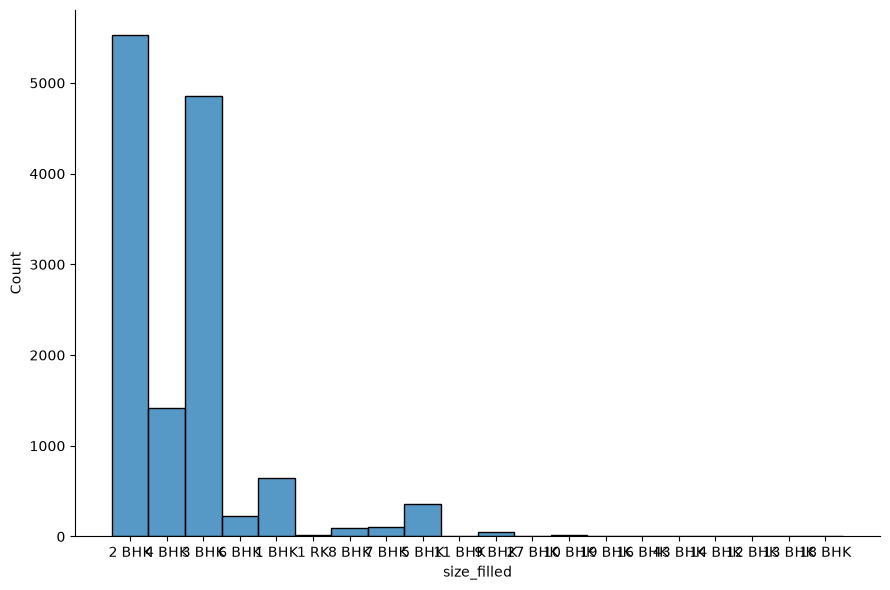

In [42]:

sns.displot(df['size_filled'], height=6, aspect=1.5)

In [43]:
#the size_filled column is heavily skewed to wards 1bhk, 2bhk and 3bhk so definitely 16, 18, 19 bhk is outlier

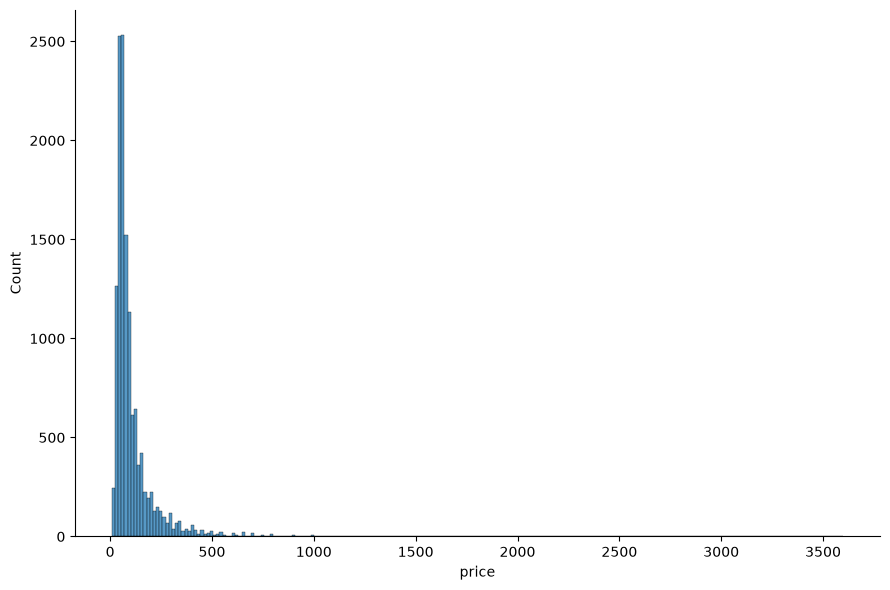

In [44]:
sns.displot(df['price'], height=6, aspect=1.5)

In [45]:
df['size_filled'].value_counts()

size_filled
2 BHK     5528
3 BHK     4857
4 BHK     1417
1 BHK      643
5 BHK      356
6 BHK      221
7 BHK      100
8 BHK       89
9 BHK       54
10 BHK      14
1 RK        13
11 BHK       4
27 BHK       1
19 BHK       1
16 BHK       1
43 BHK       1
14 BHK       1
12 BHK       1
13 BHK       1
18 BHK       1
Name: count, dtype: int64

In [46]:
df['size_filled'].describe()

count     13304
unique       20
top       2 BHK
freq       5528
Name: size_filled, dtype: object

In [47]:
df['price'].describe()

count    13304.000000
mean       112.582035
std        148.988398
min          8.000000
25%         50.000000
50%         72.000000
75%        120.000000
max       3600.000000
Name: price, dtype: float64

<Axes: ylabel='size_filled'>

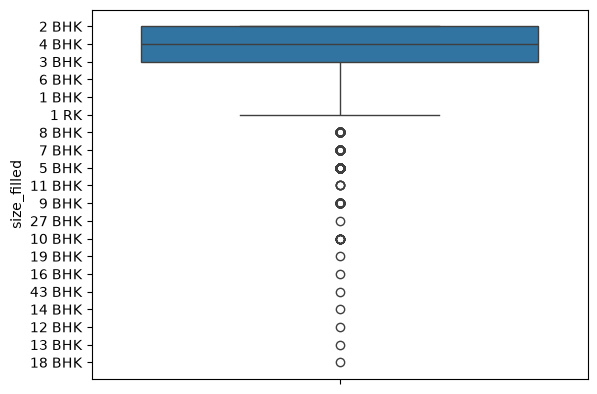

In [48]:
sns.boxplot(df['size_filled'])

In [49]:
#checking how many properties are above 5bhk and taking its percentage
df['size_filled'].value_counts()

size_filled
2 BHK     5528
3 BHK     4857
4 BHK     1417
1 BHK      643
5 BHK      356
6 BHK      221
7 BHK      100
8 BHK       89
9 BHK       54
10 BHK      14
1 RK        13
11 BHK       4
27 BHK       1
19 BHK       1
16 BHK       1
43 BHK       1
14 BHK       1
12 BHK       1
13 BHK       1
18 BHK       1
Name: count, dtype: int64

In [50]:
above5 = 221 + 100 + 89 + 54 + 14 + 13 + 4 + 8 
above5

503

In [51]:
(above5 / df.shape[0]) * 100

3.7808177991581484

In [52]:
allowed_bhk = ["1 BHK", "2 BHK", "3 BHK", "4 BHK", "5 BHK"]
df = df[df['size_filled'].isin(allowed_bhk)]

In [53]:
df.info()

<class 'pandas.DataFrame'>
Index: 12801 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     12801 non-null  str    
 1   availability  12801 non-null  str    
 2   location      12800 non-null  str    
 3   size          12801 non-null  str    
 4   total_sqft    12801 non-null  str    
 5   bath          12801 non-null  float64
 6   balcony       12801 non-null  float64
 7   price         12801 non-null  float64
 8   size_filled   12801 non-null  str    
dtypes: float64(3), str(6)
memory usage: 1000.1 KB


In [54]:
# Removed 503 properties with >5 BHK (3.78% of data)
# Reasoning: 6+ BHK properties represent luxury/commercial segment
# which is a different market from typical residential properties.
# Including them would introduce noise for the primary use case.
# Model scope: predicting 1-5 BHK residential property prices in Bengaluru.

In [55]:
df.loc[df['availability'] != 'Ready To Move', 'availability'] = 'Not Ready To Move'

In [56]:
df['availability']

0        Not Ready To Move
1            Ready To Move
2            Ready To Move
3            Ready To Move
4            Ready To Move
               ...        
13315        Ready To Move
13316        Ready To Move
13317        Ready To Move
13318    Not Ready To Move
13319        Ready To Move
Name: availability, Length: 12801, dtype: str

Decision taken till now as data cleansing..
1. appended a column as a substitute for size column. The newly added column has BHK rather than bedroom and BHK both as from original size column.
2. imputed values for Bath and balcony for NaN with actual median value with respect to size
3. removed society column fully as it had more than 5k empty values which is around 41% of data and any way that same parameter is getting handled using location column.
4. removed the outliers from size_filled column took help from boxplot and saw that more than 5BHK are just around 500 rows in 13k dataset which is approx 3.78% also, from the business point of view it is not checking for luxury housing market.
5. For all the rows under availabilty column having values of dates are converted to Not Ready To Move

In [57]:
df['total_sqft'].value_counts()

total_sqft
1200           736
1100           221
1500           188
1000           163
2400           163
              ... 
1020 - 1130      1
2758             1
1133 - 1384      1
774              1
4689             1
Name: count, Length: 2074, dtype: int64

In [58]:
# Rows where total_sqft is not a plain number
non_numeric = df[~df['total_sqft'].str.replace('.','',regex=False).str.isnumeric()]
print(non_numeric['total_sqft'].unique()[:20])
print(f"Count: {len(non_numeric)}")

<StringArray>
[   '2100 - 2850',    '3010 - 3410',    '2957 - 3450',    '3067 - 8156',
    '1042 - 1105',    '1145 - 1340',    '1015 - 1540',    '1520 - 1740',
 '34.46Sq. Meter',    '1195 - 1440',    '1120 - 1145',    '4400 - 6640',
    '3090 - 5002',    '4400 - 6800',    '1160 - 1195',  '1000Sq. Meter',
    '4000 - 5249',    '1115 - 1130',  '1100Sq. Yards',      '520 - 645']
Length: 20, dtype: str
Count: 234


In [59]:
non_numeric_idx = df[~df['total_sqft'].str.replace('.','',regex=False).str.isnumeric()].index
print(f"Rows to drop: {len(non_numeric_idx)}")
print(f"Percentage: {len(non_numeric_idx)/len(df)*100:.2f}%")

Rows to drop: 234
Percentage: 1.83%


In [60]:
df = df.drop(index=non_numeric_idx)

The total_sqft column has range type of values as above. Along with that we also have Sq. Yards and Sq. Meter units. So, these have to be handled separately.
The range values can be handled with midpoint replacement maybe instead of median replacement
And the units can be converted to the sqft unit.
also 234 rows among 12,800 is still less than ~2% only.
So, better to get rid of these 234 rows from the data.


In [61]:
df['total_sqft'] = df['total_sqft'].astype(float)

In [62]:
df['total_sqft'].describe()

count    12567.000000
mean      1528.472203
std       1126.865984
min          1.000000
25%       1100.000000
50%       1274.000000
75%       1652.250000
max      52272.000000
Name: total_sqft, dtype: float64

In [63]:
print(df[df['total_sqft'] < 100]['total_sqft'].value_counts())

total_sqft
11.0    1
15.0    1
24.0    1
1.0     1
45.0    1
60.0    1
Name: count, dtype: int64


In [64]:
wron_data_entry = df[df['total_sqft'] < 100][['total_sqft', 'size_filled', 'price']]

In [65]:
print(f"Rows below 300 sqft: {len(df[df['total_sqft'] < 300])}")
print(f"Percentage: {len(df[df['total_sqft'] < 300])/len(df)*100:.2f}%")

# Also look at them
print(df[df['total_sqft'] < 300][['total_sqft', 'size_filled', 'price']].head(20))

Rows below 300 sqft: 9
Percentage: 0.07%
       total_sqft size_filled  price
119         276.0       2 BHK   23.0
349          11.0       3 BHK   74.0
1020         15.0       1 BHK   30.0
1122         24.0       5 BHK  150.0
4086          1.0       4 BHK  120.0
5970         45.0       1 BHK   23.0
10526       284.0       1 BHK    8.0
11558        60.0       4 BHK  218.0
13216       250.0       1 BHK   40.0


In [66]:
df = df[df['total_sqft'] >= 300]

In [67]:
print(df['total_sqft'].describe())
print(f"\nRows above 10000 sqft: {len(df[df['total_sqft'] > 10000])}")

count    12558.000000
mean      1529.490698
std       1126.622726
min        300.000000
25%       1100.000000
50%       1275.000000
75%       1653.000000
max      52272.000000
Name: total_sqft, dtype: float64

Rows above 10000 sqft: 16


In [68]:
df.info()

<class 'pandas.DataFrame'>
Index: 12558 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     12558 non-null  str    
 1   availability  12558 non-null  str    
 2   location      12557 non-null  str    
 3   size          12558 non-null  str    
 4   total_sqft    12558 non-null  float64
 5   bath          12558 non-null  float64
 6   balcony       12558 non-null  float64
 7   price         12558 non-null  float64
 8   size_filled   12558 non-null  str    
dtypes: float64(4), str(5)
memory usage: 981.1 KB


after removing the ranges and mismatched units from total_sqft there were some outliers were remaining like 1 sqft, 60 sqft and so on and the minimum standard housing size in bengaluru should be in the range of 350-400 sqft atleast so removed all the columns which are below 300 sqft.

In [69]:
df['location'].value_counts()

location
Whitefield                                         515
Sarjapur  Road                                     386
Electronic City                                    301
Kanakpura Road                                     264
Thanisandra                                        219
                                                  ... 
Kanakapur main road                                  1
Sarvobhogam Nagar                                    1
12th cross srinivas nagar banshankari 3rd stage      1
Havanur extension                                    1
Abshot Layout                                        1
Name: count, Length: 1227, dtype: int64

In [70]:
from sklearn.model_selection import KFold

In [71]:
df.info()

<class 'pandas.DataFrame'>
Index: 12558 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     12558 non-null  str    
 1   availability  12558 non-null  str    
 2   location      12557 non-null  str    
 3   size          12558 non-null  str    
 4   total_sqft    12558 non-null  float64
 5   bath          12558 non-null  float64
 6   balcony       12558 non-null  float64
 7   price         12558 non-null  float64
 8   size_filled   12558 non-null  str    
dtypes: float64(4), str(5)
memory usage: 981.1 KB


In [72]:
df['availability'].value_counts()

availability
Ready To Move        10001
Not Ready To Move     2557
Name: count, dtype: int64

In [73]:
df = df.drop(columns=['size'])

In [74]:
df.info()

<class 'pandas.DataFrame'>
Index: 12558 entries, 0 to 13319
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     12558 non-null  str    
 1   availability  12558 non-null  str    
 2   location      12557 non-null  str    
 3   total_sqft    12558 non-null  float64
 4   bath          12558 non-null  float64
 5   balcony       12558 non-null  float64
 6   price         12558 non-null  float64
 7   size_filled   12558 non-null  str    
dtypes: float64(4), str(4)
memory usage: 883.0 KB


location wise the price would vary a lot. Just check once what's the correlation between location and price? but the location is a categorical value. so category vs numeric

more total_sqft means more price simple direct correlation? numeric vs numeric
more bath means more price numeric vs numeric
more balcony means more price numeric vs numeric
more bhk means more price category vs numeric?

how area_type and availability can affect the price? I guess the earliest is the date of availability is more the price would be ? but since I converted all the dates to not ready to move then it just gets binary there...


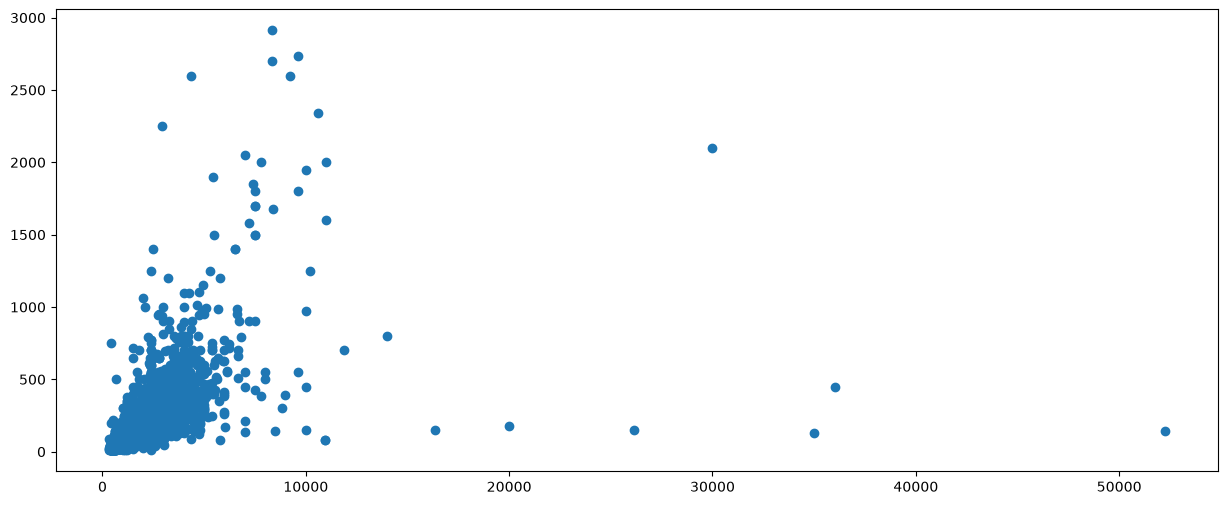

In [75]:
plt.figure(figsize=(15,6))
plt.scatter(df['total_sqft'], df['price'])
plt.show()

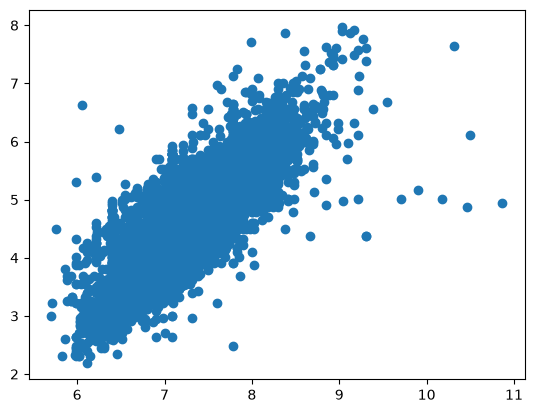

In [76]:
import numpy as np
plt.scatter(np.log(df['total_sqft']), np.log(df['price']))

In [77]:
df['total_sqft'].corr(df['price'])

np.float64(0.5919896683814135)

In [78]:
df['bath'].corr(df['price'])

np.float64(0.5326075165765577)

In [79]:
df['balcony'].corr(df['price'])

np.float64(0.1263774449477653)

In [80]:
df.groupby('size_filled')['price'].describe()

,count,mean,std,min,25%,50%,75%,max
size_filled,,,,,,,,
1 BHK,588.0,45.333878,57.328345,9.0,23.0,34.710,48.0,750.0
2 BHK,5472.0,59.608600,30.303943,10.5,42.5,53.685,69.0,650.0
3 BHK,4795.0,111.141666,87.445655,12.0,65.0,89.000,125.0,2000.0
4 BHK,1355.0,272.976664,267.385392,24.5,129.0,204.000,325.0,2912.0
5 BHK,348.0,280.764368,333.425277,44.5,120.0,177.500,300.0,2736.0


In [81]:
# Find the expensive 1 BHKs
expensive_1bhk = df[(df['size_filled'] == '1 BHK') & (df['price'] > 200)]
print(expensive_1bhk[['location', 'total_sqft', 'bath', 'price']].sort_values('price', ascending=False).head(10))

                       location  total_sqft  bath  price
7657             Raghuvanahalli       425.0   1.0  750.0
3539               Kundalahalli      2400.0   1.0  650.0
7088                Srirampuram       650.0   1.0  500.0
6549              Shivaji Nagar      3820.0   1.0  306.0
9512        5th Block Jayanagar      1500.0   1.0  300.0
12508  Electronic City Phase II      1200.0   1.0  295.0
7008                 Kudlu Gate      1400.0   1.0  285.0
7824        Sector 1 HSR Layout      6000.0   1.0  276.0
12337          Thyagaraja Nagar      1675.0   1.0  241.0
9047                Vijayanagar      2400.0   2.0  230.0


In [82]:
# Find the expensive 2 BHKs
expensive_1bhk = df[(df['size_filled'] == '2 BHK') & (df['price'] > 200)]
print(expensive_1bhk[['location', 'total_sqft', 'bath', 'price']].sort_values('price', ascending=False).head(10))

                    location  total_sqft  bath  price
5265     8th Block Jayanagar      2800.0   2.0  650.0
2239             Ngef Layout      3000.0   2.0  510.0
1370            Amruthahalli      4400.0   3.0  475.0
9156        Nandi Durga Road      2015.0   4.0  325.0
7041             Anand Nagar      1800.0   2.0  300.0
11856           Kalyan nagar      8840.0   2.0  300.0
6667      Vittal Mallya Road      1030.0   2.0  300.0
3806            Rajaji Nagar      1718.0   3.0  288.0
4846   Thanisandra main road      1804.0   2.0  285.0
13167            Benson Town      1688.0   2.0  280.0


In [83]:
df['price_per_sqft'] = (df['price'] * 100000) / df['total_sqft']
print(df['price_per_sqft'].describe())

count     12558.000000
mean       6486.682395
std        4287.787241
min         267.829813
25%        4243.305621
50%        5381.801090
75%        7102.119109
max      176470.588235
Name: price_per_sqft, dtype: float64


In [84]:
import seaborn as sns

<Axes: xlabel='price', ylabel='Count'>

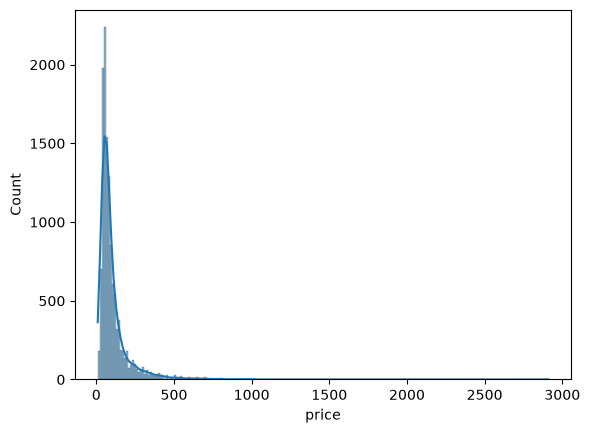

In [85]:
sns.histplot(data=df, x='price',kde=True)

<Axes: xlabel='price'>

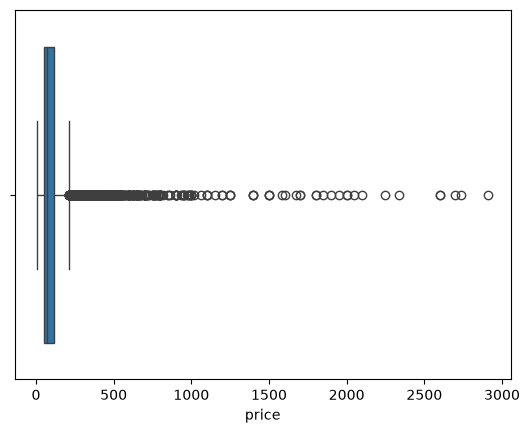

In [86]:
sns.boxplot(data=df, x='price')

<Axes: xlabel='total_sqft', ylabel='Count'>

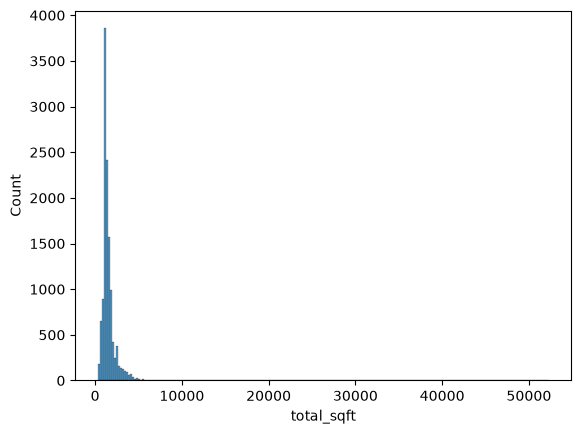

In [87]:
sns.histplot(data=df, x='total_sqft')

<Axes: xlabel='total_sqft'>

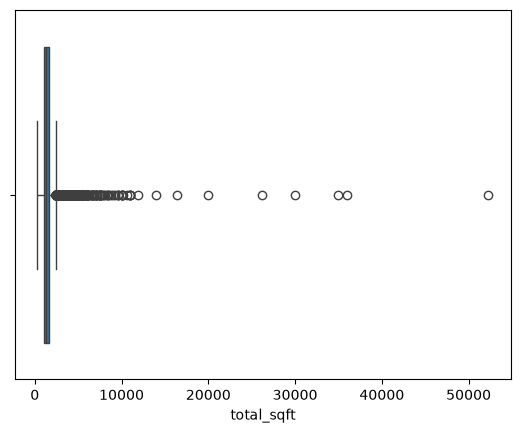

In [88]:
sns.boxplot(data=df, x='total_sqft')

<Axes: xlabel='bath', ylabel='Count'>

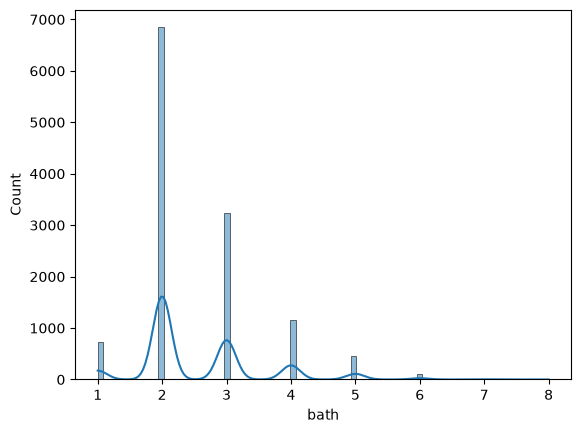

In [89]:
sns.histplot(data=df, x='bath',kde=True)

<Axes: xlabel='balcony', ylabel='Count'>

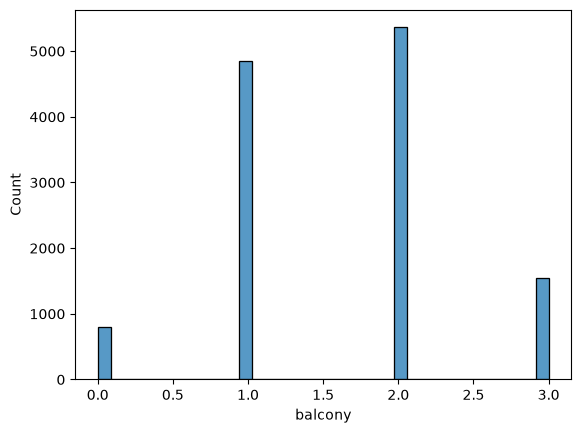

In [90]:
sns.histplot(data=df, x='balcony')

<Axes: xlabel='total_sqft', ylabel='price'>

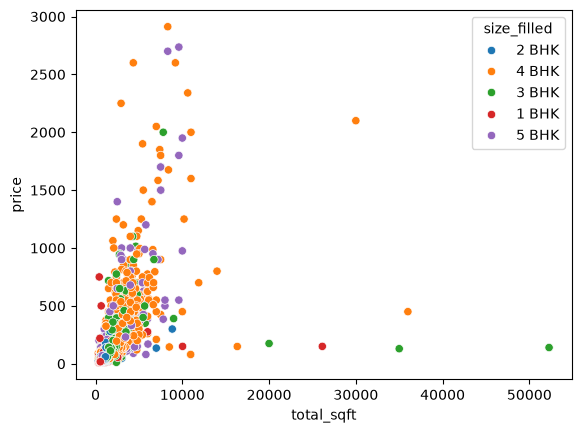

In [91]:
sns.scatterplot(data=df, x='total_sqft', y='price',hue='size_filled')

<Axes: xlabel='total_sqft', ylabel='price'>

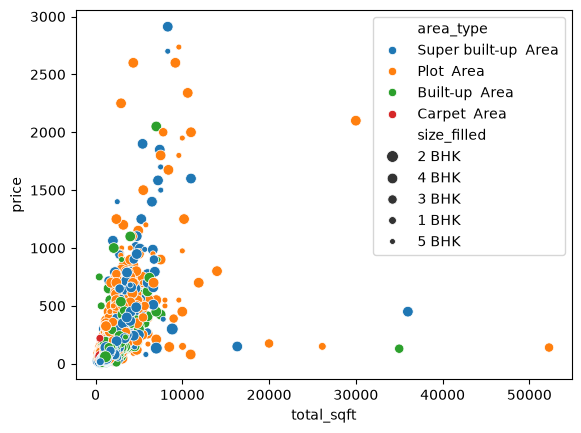

In [92]:
sns.scatterplot(data=df, x='total_sqft', y='price', hue='area_type', size='size_filled')

<Axes: xlabel='size_filled', ylabel='price'>

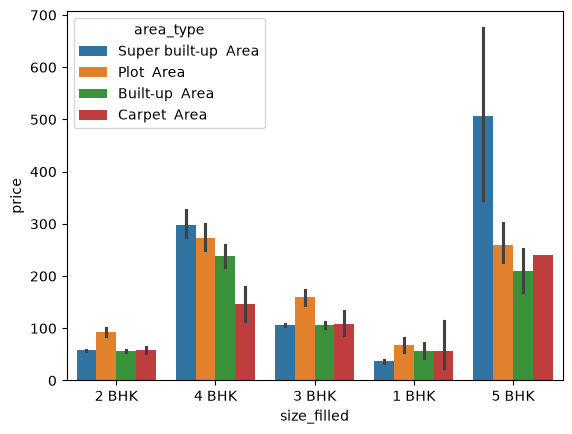

In [93]:
sns.barplot(data=df, x='size_filled', y='price', hue='area_type')

In [94]:
df.groupby('size_filled')['area_type'].describe()

,count,unique,top,freq
size_filled,,,,
1 BHK,588,4,Super built-up Area,370
2 BHK,5472,4,Super built-up Area,4152
3 BHK,4795,4,Super built-up Area,3544
4 BHK,1355,4,Plot Area,625
5 BHK,348,4,Plot Area,237


<Axes: xlabel='availability', ylabel='price'>

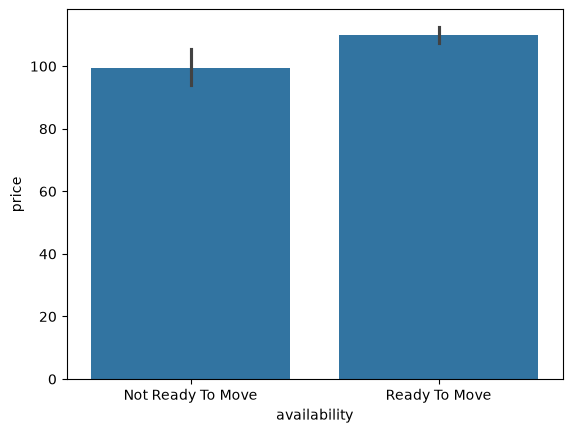

In [95]:
sns.barplot(data=df, x='availability', y='price')

<Axes: xlabel='area_type', ylabel='price'>

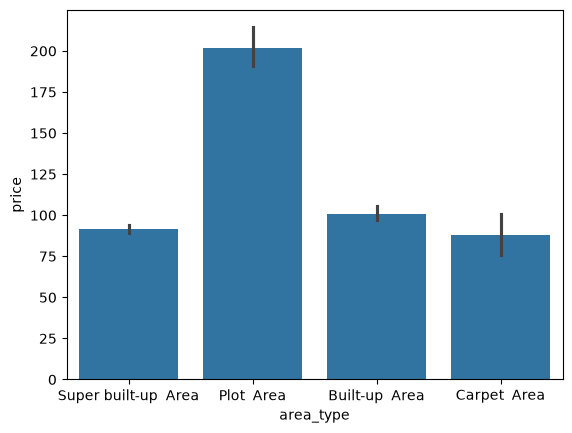

In [96]:
sns.barplot(data=df, x='area_type', y='price')

<Axes: xlabel='size_filled', ylabel='price'>

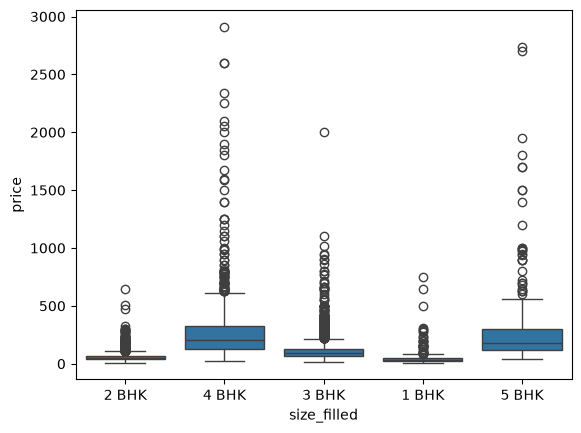

In [97]:
#categorical column and target column (numerical)
sns.boxplot(data=df, x='size_filled', y='price')

In [98]:
df['area_type'].value_counts()

area_type
Super built-up  Area    8543
Built-up  Area          2290
Plot  Area              1649
Carpet  Area              76
Name: count, dtype: int64

In [99]:
df['price_per_sqft']

0         3699.810606
1         4615.384615
2         4305.555556
3         6245.890861
4         4250.000000
             ...     
13315     6689.834926
13316    11111.111111
13317     5258.545136
13318    10407.336319
13319     3090.909091
Name: price_per_sqft, Length: 12558, dtype: float64

In [100]:
df.groupby('area_type')['price_per_sqft'].median()

area_type
Built-up  Area           5113.978230
Carpet  Area             6017.142857
Plot  Area              10000.000000
Super built-up  Area     5130.111524
Name: price_per_sqft, dtype: float64

In [101]:
df.groupby('location')['price_per_sqft'].agg(['mean', 'median', 'count'])

,mean,median,count
location,,,
Devarabeesana Halli,7900.452568,8542.857143,6
Devarachikkanahalli,4969.906245,4305.148257,14
Mysore Highway,4461.458189,4235.221675,4
Sector 1 HSR Layout,4600.000000,4600.000000,1
ittamadu,18333.333333,18333.333333,1
...,...,...,...
sapthagiri Layout,8846.153846,8846.153846,1
sarjapura main road,10416.666667,10416.666667,1
singapura paradise,11666.666667,11666.666667,1


In [102]:
df[df['location'] == 'Whitefield'].value_counts()

area_type             availability       location    total_sqft  bath  balcony  price   size_filled  price_per_sqft
Super built-up  Area  Not Ready To Move  Whitefield  1216.0      2.0   1.0      75.00   2 BHK        6167.763158       5
Plot  Area            Not Ready To Move  Whitefield  1200.0      2.0   1.0      45.00   2 BHK        3750.000000       4
Super built-up  Area  Ready To Move      Whitefield  1116.0      2.0   3.0      51.91   2 BHK        4651.433692       3
Plot  Area            Not Ready To Move  Whitefield  1200.0      2.0   1.0      46.13   2 BHK        3844.166667       3
Super built-up  Area  Ready To Move      Whitefield  1116.0      2.0   1.0      51.91   2 BHK        4651.433692       2
                                                                                                                      ..
                      Not Ready To Move  Whitefield  613.0       1.0   1.0      48.00   1 BHK        7830.342577       1
                      Ready To Move  

In [103]:
df['location'].value_counts()

location
Whitefield                                         515
Sarjapur  Road                                     386
Electronic City                                    301
Kanakpura Road                                     264
Thanisandra                                        219
                                                  ... 
Kanakapur main road                                  1
Sarvobhogam Nagar                                    1
12th cross srinivas nagar banshankari 3rd stage      1
Havanur extension                                    1
Abshot Layout                                        1
Name: count, Length: 1227, dtype: int64

In [104]:
df = df.drop(columns=['area_type'])


## Feature Selection Decision

### Created `price_per_sqft` and Removed `area_type`

* A new feature, **`price_per_sqft`**, was calculated using the existing **price** and **`total_sqft`** values.
* This derived feature provides a more granular representation of the property's price relative to its reported area.
* Since the dataset also contains **`location`**, the calculated `price_per_sqft` helps capture the **location-wise price premium**. Properties in different locations can have significantly different price levels, and the price per square foot provides a way to represent this variation.
* The `area_type` column contains only four broad categories: **Plot Area, Carpet Area, Built-up Area, and Super Built-up Area**. These categories represent different definitions of area and therefore do not have the same meaning in terms of the actual area of an individual house.
* For example, in the case of **Plot Area**, the `total_sqft` value can represent the area of the entire plot/building rather than the actual area of an individual house. Therefore, using `area_type` as an important feature could introduce ambiguity when interpreting the relationship between area and price.
* Instead, the calculated `price_per_sqft` provides a more direct measure of the **price relative to the reported area**, while also capturing the pricing variation associated with different locations.
* Based on this reasoning, the **`area_type` column was removed**, and the newly calculated **`price_per_sqft` feature was retained** for further analysis and model building.


In [105]:
df.info()

<class 'pandas.DataFrame'>
Index: 12558 entries, 0 to 13319
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   availability    12558 non-null  str    
 1   location        12557 non-null  str    
 2   total_sqft      12558 non-null  float64
 3   bath            12558 non-null  float64
 4   balcony         12558 non-null  float64
 5   price           12558 non-null  float64
 6   size_filled     12558 non-null  str    
 7   price_per_sqft  12558 non-null  float64
dtypes: float64(5), str(3)
memory usage: 883.0 KB


In [106]:
missing_location = df[df['location'].isna()]
df = df.drop(index=missing_location.index)

In [107]:
df.info()

<class 'pandas.DataFrame'>
Index: 12557 entries, 0 to 13319
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   availability    12557 non-null  str    
 1   location        12557 non-null  str    
 2   total_sqft      12557 non-null  float64
 3   bath            12557 non-null  float64
 4   balcony         12557 non-null  float64
 5   price           12557 non-null  float64
 6   size_filled     12557 non-null  str    
 7   price_per_sqft  12557 non-null  float64
dtypes: float64(5), str(3)
memory usage: 882.9 KB


<Axes: >

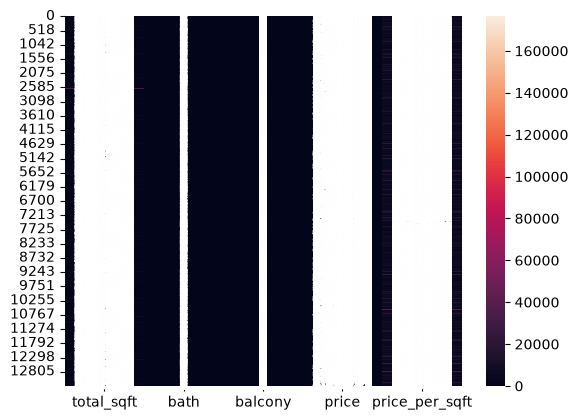

In [108]:
sns.heatmap(df.select_dtypes(include='number'), annot=True)

In [109]:
df.to_csv('cleaned_housing_dataset.csv', index=False)

In [110]:
duplicates = df[df.duplicated(keep=False)]
duplicates.sort_values('location').head(20)

,availability,location,total_sqft,bath,balcony,price,size_filled,price_per_sqft
7200,Ready To Move,2nd Block Bel Layout,1625.0,3.0,3.0,92.00,3 BHK,5661.538462
12126,Ready To Move,2nd Block Bel Layout,1625.0,3.0,3.0,92.00,3 BHK,5661.538462
1905,Ready To Move,2nd Block Hrbr Layout,1480.0,3.0,2.0,90.00,3 BHK,6081.081081
1077,Ready To Move,2nd Block Hrbr Layout,1480.0,3.0,2.0,90.00,3 BHK,6081.081081
7051,Ready To Move,2nd Phase Judicial Layout,1350.0,2.0,2.0,47.25,3 BHK,3500.000000
13107,Ready To Move,2nd Phase Judicial Layout,1150.0,2.0,1.0,40.25,2 BHK,3500.000000
2060,Ready To Move,2nd Phase Judicial Layout,1150.0,2.0,1.0,40.25,2 BHK,3500.000000
12317,Ready To Move,2nd Phase Judicial Layout,1350.0,2.0,2.0,47.25,3 BHK,3500.000000
8844,Ready To Move,2nd Phase Judicial Layout,1350.0,2.0,2.0,47.25,3 BHK,3500.000000
10483,Ready To Move,2nd Stage Nagarbhavi,1200.0,4.0,3.0,240.00,5 BHK,20000.000000


In [111]:
print(f"Duplicates: {937/len(df)*100:.1f}%")

Duplicates: 7.5%


In [112]:
df = df.drop_duplicates()

In [113]:
df.shape

(11848, 8)

Dropped 937 duplicate rows (7.5% of data)
All duplicates had identical values across all columns including price decimals
Likely same property listed multiple times by different agents or scraping artifact
Retaining first occurrence of each duplicate

In [114]:
df.info()

<class 'pandas.DataFrame'>
Index: 11848 entries, 0 to 13318
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   availability    11848 non-null  str    
 1   location        11848 non-null  str    
 2   total_sqft      11848 non-null  float64
 3   bath            11848 non-null  float64
 4   balcony         11848 non-null  float64
 5   price           11848 non-null  float64
 6   size_filled     11848 non-null  str    
 7   price_per_sqft  11848 non-null  float64
dtypes: float64(5), str(3)
memory usage: 833.1 KB


numerical transformation -> total_sqft, bath, balcony, price_per_sqft
categorical transformation -> location - using target encoding, size_filled - OHE, availability - OHE

In [115]:
counts = df['location'].value_counts()
rare_locations = counts[counts < 10].index
df['location'] = df['location'].replace(rare_locations, 'other_rare_location')

df['location'].value_counts()

location
other_rare_location      2624
Whitefield                489
Sarjapur  Road            358
Electronic City           281
Kanakpura Road            218
                         ... 
Kalkere                    10
Marsur                     10
Laggere                    10
1st Block Koramangala      10
Gunjur Palya               10
Name: count, Length: 238, dtype: int64

In [119]:
df['size_filled'].unique()

<StringArray>
['2 BHK', '4 BHK', '3 BHK', '1 BHK', '5 BHK']
Length: 5, dtype: str

In [120]:
#sqft per bhk...
all_bhk = df['size_filled'].values
bhkNumbers = df['size_filled'].str.replace('BHK', '', regex=False).str.strip().astype(int)

df['sqft_perBHK'] = df['total_sqft'] / bhkNumbers
df['sqft_perBHK']

df.info()

<class 'pandas.DataFrame'>
Index: 11848 entries, 0 to 13318
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   availability    11848 non-null  str    
 1   location        11848 non-null  str    
 2   total_sqft      11848 non-null  float64
 3   bath            11848 non-null  float64
 4   balcony         11848 non-null  float64
 5   price           11848 non-null  float64
 6   size_filled     11848 non-null  str    
 7   price_per_sqft  11848 non-null  float64
 8   total_sqft_log  11848 non-null  float64
 9   sqft_perBHK     11848 non-null  float64
dtypes: float64(7), str(3)
memory usage: 1018.2 KB


In [118]:
df['total_sqft_log'] = np.log1p(df['total_sqft'])
df.info()

<class 'pandas.DataFrame'>
Index: 11848 entries, 0 to 13318
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   availability    11848 non-null  str    
 1   location        11848 non-null  str    
 2   total_sqft      11848 non-null  float64
 3   bath            11848 non-null  float64
 4   balcony         11848 non-null  float64
 5   price           11848 non-null  float64
 6   size_filled     11848 non-null  str    
 7   price_per_sqft  11848 non-null  float64
 8   total_sqft_log  11848 non-null  float64
dtypes: float64(6), str(3)
memory usage: 925.6 KB


In [123]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import TargetEncoder
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.metrics import root_mean_squared_error
from sklearn.ensemble import RandomForestRegressor

#1. train test split
X = df.drop(columns=['price', 'price_per_sqft', 'total_sqft'])
y = df['price']
y_log = np.log1p(y)

X_train, X_test, y_train, y_test = train_test_split(X, y_log, test_size=0.2, random_state=42)

#2. categorizing the columns
numerical_cols = ["total_sqft_log", "bath", "balcony", "sqft_perBHK"]
category_cols = ["size_filled", "availability"]
location_col = ['location']

#3. Making ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('numeric', StandardScaler(), numerical_cols),
        ('categorical', OneHotEncoder(), category_cols),
        ('location', TargetEncoder(categories='auto', cv=5, smooth='auto', random_state=42), location_col)
    ]
)

#4. model
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    # ('regressor', RandomForestRegressor(n_estimators=100, max_depth=20, min_samples_leaf=4, min_samples_split=2, random_state=42))
    ('xgbregressor', XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42))
    # ('regressor', LinearRegression())
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

y_pred_ruppes = np.expm1(y_pred)
y_test_ruppes = np.expm1(y_test)

print(r2_score(y_test_ruppes, y_pred_ruppes))
print(root_mean_squared_error(y_test_ruppes, y_pred_ruppes))

print("min/max", y_pred.min(), y_pred.max())


/Users/apple/Developer/ML/bangalore-house-price-prediction/.venv/lib/python3.14/site-packages/sklearn/preprocessing/_target_encoder.py:342: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


0.590077346519653
84.80663140233808
min/max 2.5117333 7.4662366


In [ ]:
gridSearchCV

In [124]:
print(X.columns.tolist())

['availability', 'location', 'bath', 'balcony', 'size_filled', 'total_sqft_log', 'sqft_perBHK']


In [122]:
y_train_pred = model.predict(X_train)
print("Train R2:", r2_score(np.expm1(y_train), np.expm1(y_train_pred)))
print("Test R2:", r2_score(y_test_ruppes, y_pred_ruppes))

Train R2: 0.3697125088893295
Test R2: 0.33012208042234703


In [233]:
print("Type y_test_ruppes:", type(y_test_ruppes))
print("Type y_pred_ruppes:", type(y_pred_ruppes))
print("Shape y_test_ruppes:", y_test_ruppes.shape)
print("Shape y_pred_ruppes:", y_pred_ruppes.shape)
print("Any NaN in y_test_ruppes:", np.isnan(y_test_ruppes).any())
print("Any NaN in y_pred_ruppes:", np.isnan(y_pred_ruppes).any())
print("Any inf in y_pred_ruppes:", np.isinf(y_pred_ruppes).any())
print("Min/Max y_test_ruppes:", y_test_ruppes.min(), y_test_ruppes.max())
print("Min/Max y_pred_ruppes:", y_pred_ruppes.min(), y_pred_ruppes.max())

Type y_test_ruppes: <class 'pandas.core.series.Series'>
Type y_pred_ruppes: <class 'numpy.ndarray'>
Shape y_test_ruppes: (2370,)
Shape y_pred_ruppes: (2370,)
Any NaN in y_test_ruppes: False
Any NaN in y_pred_ruppes: False
Any inf in y_pred_ruppes: False
Min/Max y_test_ruppes: 10.000000000000002 2250.0000000000005
Min/Max y_pred_ruppes: 15.47357879783873 1904.016775864289


In [235]:
# Check predictions directly on log scale before inverse transform
print("R2 on log scale:", r2_score(y_test, y_pred))
print("RMSE on log scale:", root_mean_squared_error(y_test, y_pred))
print("y_pred_log min/max:", y_pred.min(), y_pred.max())
print("y_test min/max:", y_test.min(), y_test.max())

R2 on log scale: 0.7362031575234519
RMSE on log scale: 0.34972234842371547
y_pred_log min/max: 2.8017578125 7.55224609375
y_test min/max: 2.3978952727983707 7.719129840906732


In [234]:
# Find which predictions are wildly off
results = pd.DataFrame({
    'actual': y_test_ruppes.values,
    'predicted': y_pred_ruppes,
    'location': X_test['location'].values
})

print(results[results['predicted'] > 1000].sort_values('predicted', ascending=False).head(20))

    actual    predicted         location
44  1800.0  1904.016776  Cunningham Road


In [160]:
print(df[df['location'] == 'Nelamangala'][['location', 'price', 'total_sqft', 'size_filled']])

         location  price  total_sqft size_filled
1894  Nelamangala  140.0     52272.0       3 BHK
2167  Nelamangala   40.0      1095.0       2 BHK
2223  Nelamangala   34.5      1470.0       4 BHK
3331  Nelamangala   24.0       820.0       2 BHK
5049  Nelamangala   72.0      1200.0       3 BHK
5538  Nelamangala   95.0      2600.0       4 BHK
7699  Nelamangala   90.0      1500.0       3 BHK
8243  Nelamangala   30.0       820.0       2 BHK


In [162]:
counts = df['location'].value_counts()

total_single = (counts == 1).sum()
print("how many are appeared just once", total_single)

betweenOneAndTen = (counts > 1).sum() and (counts < 10).sum()
print("how many are between 1 and 10", betweenOneAndTen)

how many are appeared just once 441
how many are between 1 and 10 990


In [191]:
# Check X_test after the location replacement
print(X_test['location'].value_counts().head())
print(X_test.shape)
print(X_train.shape)

location
other_rare_location    547
Whitefield              92
Sarjapur  Road          73
Electronic City         57
Yelahanka               46
Name: count, dtype: int64
(2370, 7)
(9478, 7)


In [192]:
# Check predictions directly on log scale before inverse transform
print("R2 on log scale:", r2_score(y_test, y_pred_log))
print("RMSE on log scale:", root_mean_squared_error(y_test, y_pred_log))
print("y_pred_log min/max:", y_pred_log.min(), y_pred_log.max())
print("y_test min/max:", y_test.min(), y_test.max())

R2 on log scale: 0.6229458817926468
RMSE on log scale: 0.418109883604293
y_pred_log min/max: 3.07470703125 14.035888671875
y_test min/max: 2.3978952727983707 7.719129840906732


In [193]:
# Max realistic price in your dataset
max_log_price = y_train.max()
min_log_price = y_train.min()

y_pred_log_clipped = np.clip(y_pred_log, min_log_price, max_log_price)
y_pred_rupees = np.expm1(y_pred_log_clipped)
y_test_rupees = np.expm1(y_test)

print("R2:", r2_score(y_test_rupees, y_pred_rupees))
print("RMSE:", root_mean_squared_error(y_test_rupees, y_pred_rupees))

R2: 0.31698722988227246
RMSE: 109.46953294101593


In [194]:
extreme_idx = np.where(y_pred_log > y_train.max())[0]
print(f"Extreme predictions count: {len(extreme_idx)}")
print(X_test.iloc[extreme_idx]['location'].value_counts())

Extreme predictions count: 1
location
other_rare_location    1
Name: count, dtype: int64


the more total_sqft of 2bhk will always command higher price than the lesser one sq_ft per bhk
so let's derived one more feature sqft per bhk the more the better property value..